Big Mart Sales Data Analysis

In [17]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load dataset
df = pd.read_csv('./data/bigmart_train.csv')
df.shape

(8523, 12)

In [3]:
# check the types of colums
df.dtypes

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

In [4]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Data Cleaning

In [5]:
'''
Categorical data: Item_Type,Outlet_Type,Outlet_Size,item_fat_content,Outletsize
Numerical data: Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
'''

'\nCategorical data: Item_Type,Outlet_Type,Outlet_Size,item_fat_content,Outletsize\nNumerical data: Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales\n'

In [6]:
df['Item_Weight'].isna().sum()

np.int64(1463)

In [7]:
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)


In [8]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [9]:
# Replace maaping of old names with new ones 
clean_map = {
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
}
# Apply transfromation 
df['Item_Fat_Content']=df['Item_Fat_Content'].replace(clean_map)
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [10]:
df['Outlet_Size'].isna().sum()

np.int64(2410)

In [11]:
'''
If you treat it like normal numeric:

Mean of years → meaningless 
Correlation with sales → misleading 
Model/analysis won’t understand “time effect” properly 
'''

# created a new feature called Outlet Age eg outlet age = current_year - est_year

from datetime import datetime
current_year = datetime.now().year

df['Outlet_year'] = current_year-df['Outlet_Establishment_Year']
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
Outlet_year                     0
dtype: int64

In [12]:
mode_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size) 
# .mode() → returns list-like output [0] → extracts actual value (e.g., "Medium")

In [13]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Outlet_year                  0
dtype: int64

In [15]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_year
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39


(array([3.280e+03, 2.448e+03, 1.527e+03, 7.290e+02, 3.590e+02, 1.240e+02,
        3.600e+01, 1.600e+01, 2.000e+00, 2.000e+00]),
 array([   33.29   ,  1338.65748,  2644.02496,  3949.39244,  5254.75992,
         6560.1274 ,  7865.49488,  9170.86236, 10476.22984, 11781.59732,
        13086.9648 ]),
 <BarContainer object of 10 artists>)

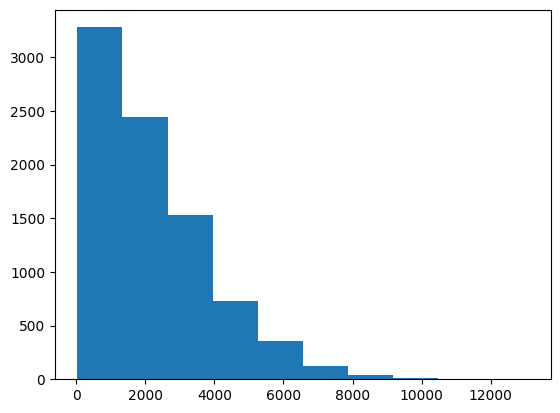

In [18]:
plt.hist(df['Item_Outlet_Sales'])


In [19]:
df['Item_Outlet_Sales'].describe()

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

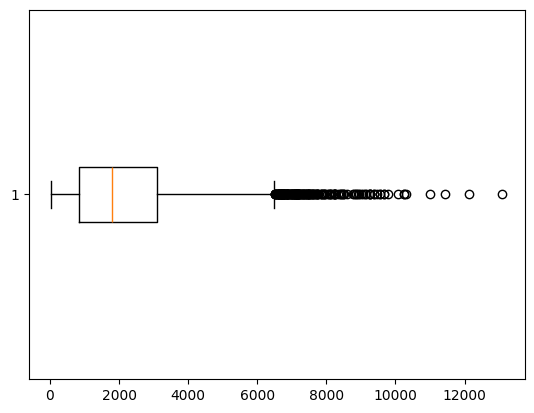

In [23]:
plt.boxplot(df['Item_Outlet_Sales'],vert=False)
plt.show()

In [24]:
# SUMMARY ANALYSIS OF ITEM_OUTLET_SALES
# 1. Distribution Shape: The data is heavily RIGHT-SKEWED (Positively Skewed).
#    - This indicates that most products/outlets generate lower to mid-range sales.
#    - A small number of observations generate exceptionally high revenue (the 'long tail').

# 2. Key Sales Thresholds:
#    - Low Sales (Bottom 25%): Items making less than $834.
#    - Typical Sales (Median): $1,794 is the "middle" value, more representative than the mean.
#    - High Sales (Top 25%): Items making more than $3,101.

# 3. The "Outlier" Effect:
#    - The gap between the 75th percentile ($3,101) and the Maximum ($13,086) is massive.
#    - These 'Outliers' (the circles in the boxplot) represent the 'Super-Performers'.
#    - Business Insight: Revenue is likely driven by a few high-performing outlets 
#      or premium product categories, while the majority of the business 
#      operates in the $800 - $3,000 range.

# 4. Data Preparation Note:
#    - Because of the high skewness and outliers, this column may need 
#      Log Transformation before training Machine Learning models to 
#      ensure the extreme values don't bias the predictions.